Number of Records: 1500

Target Labels:
['neutral' 'positive' 'negative']

Sample Customer Messages:

1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

2. I need information about the payment process.

3. The refund process was fast and convenient. I appreciate the quick response.

4. My refund is still pending and this experience is frustrating. My ticket number is 33927.

5. Please tell me how to update my account details.

Average Text Length: 12.72 words

Class Distribution:

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


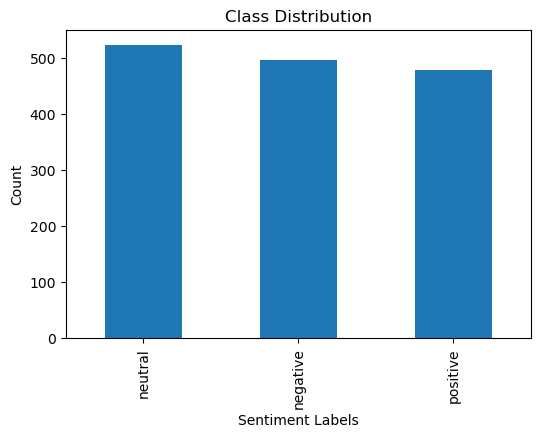

In [10]:
# Task 1: Dataset Understanding

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"E:\BITSOM\Assignment 5\Part3\customer_support_text_classification.csv")

# -----------------------------
# 1. Number of records
# -----------------------------
print("Number of Records:", len(df))

# -----------------------------
# 2. Target labels/classes
# -----------------------------
print("\nTarget Labels:")
print(df['sentiment_label'].unique())

# -----------------------------
# 3. Sample text records
# -----------------------------
print("\nSample Customer Messages:\n")

for i, text in enumerate(df['customer_message'].head(5), start=1):
    print(f"{i}. {text}\n")

# -----------------------------
# 4. Average text length
# -----------------------------

# Calculate number of words in each message
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))

average_length = df['text_length'].mean()

print("Average Text Length:", round(average_length, 2), "words")

# -----------------------------
# 5. Class distribution
# -----------------------------
print("\nClass Distribution:\n")

class_distribution = df['sentiment_label'].value_counts()

print(class_distribution)

# -----------------------------
# Visualization of class distribution
# -----------------------------
plt.figure(figsize=(6,4))

class_distribution.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Sentiment Labels")
plt.ylabel("Count")

plt.show()

In [11]:
# Task 2: Text Preprocessing

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

df = pd.read_csv(r"E:\BITSOM\Assignment 5\Part3\customer_support_text_classification.csv")

# -------------------------------------------------
# Stopwords
# -------------------------------------------------

stop_words = set(stopwords.words('english'))

# -------------------------------------------------
# Text Cleaning Function
# -------------------------------------------------

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into sentence
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -------------------------------------------------
# Apply preprocessing
# -------------------------------------------------

df['clean_text'] = df['customer_message'].apply(preprocess_text)

# -------------------------------------------------
# Display original vs cleaned text
# -------------------------------------------------

print("\nOriginal Text:\n")
print(df['customer_message'].head(3))

print("\nCleaned Text:\n")
print(df['clean_text'].head(3))

# -------------------------------------------------
# Tokenization for Sequence Models
# -------------------------------------------------

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# -------------------------------------------------
# Padding / Truncating Sequences
# -------------------------------------------------

max_length = 20

X_padded = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# -------------------------------------------------
# Output Information
# -------------------------------------------------

print("\nExample Sequence:\n")
print(sequences[0])

print("\nPadded Sequence:\n")
print(X_padded[0])

print("\nShape of Padded Data:")
print(X_padded.shape)


Original Text:

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
Name: customer_message, dtype: object

Cleaned Text:

0    need information payment process ticket number...
1                     need information payment process
2    refund process fast convenient appreciate quic...
Name: clean_text, dtype: object

Example Sequence:

[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

Padded Sequence:

[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0]

Shape of Padded Data:
(1500, 20)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Load dataset
df = pd.read_csv(r"E:\BITSOM\Assignment 5\Part3\customer_support_text_classification.csv")

# Download resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Stopwords
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join back
    cleaned_text = " ".join(tokens)

    return cleaned_text

# Create clean_text column
df['clean_text'] = df['customer_message'].apply(preprocess_text)

# Check output
print(df[['customer_message', 'clean_text']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

X_tfidf = tfidf.fit_transform(df['clean_text'])

print(X_tfidf.shape)

(1500, 146)


In [ ]:
##Method 2: Tokenizer-Based Sequences

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -------------------------------------------------
# Tokenizer
# -------------------------------------------------

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# -------------------------------------------------
# Padding Sequences
# -------------------------------------------------

max_length = 20

X_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

# -------------------------------------------------
# Output
# -------------------------------------------------

print("Sequence Shape:")
print(X_sequences.shape)

print("\nExample Sequence:\n")
print(sequences[0])

print("\nPadded Sequence:\n")
print(X_sequences[0])

Sequence Shape:
(1500, 20)

Example Sequence:

[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

Padded Sequence:

[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy Score:
1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



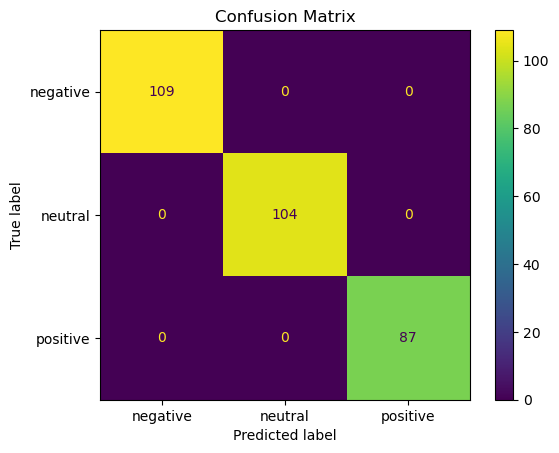

In [20]:
# Task 4: Baseline Model

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

df = pd.read_csv(r"E:\BITSOM\Assignment 5\Part3\customer_support_text_classification.csv")

# -------------------------------------------------
# Download NLTK Resources
# -------------------------------------------------

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# -------------------------------------------------
# Stopwords
# -------------------------------------------------

stop_words = set(stopwords.words('english'))

# -------------------------------------------------
# Preprocessing Function
# -------------------------------------------------

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join words
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -------------------------------------------------
# Create clean_text column
# -------------------------------------------------

df['clean_text'] = df['customer_message'].apply(preprocess_text)

# -------------------------------------------------
# Inputs and Labels
# -------------------------------------------------

X_text = df['clean_text']

y = df['sentiment_label']

# -------------------------------------------------
# TF-IDF Vectorization
# -------------------------------------------------

tfidf = TfidfVectorizer(max_features=500)

X = tfidf.fit_transform(X_text)

# -------------------------------------------------
# Train-Test Split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------------------------------
# Logistic Regression Model
# -------------------------------------------------

model = LogisticRegression()

model.fit(X_train, y_train)

# -------------------------------------------------
# Predictions
# -------------------------------------------------

y_pred = model.predict(X_test)

# -------------------------------------------------
# Evaluation
# -------------------------------------------------

print("Accuracy Score:")

print(accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# -------------------------------------------------
# Confusion Matrix
# -------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [14]:
# Task 5: Sequence Model using LSTM

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# -------------------------------------------------
# Load Dataset
# -------------------------------------------------

df = pd.read_csv(r"E:\BITSOM\Assignment 5\Part3\customer_support_text_classification.csv")

# -------------------------------------------------
# Download NLTK Resources
# -------------------------------------------------

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# -------------------------------------------------
# Stopwords
# -------------------------------------------------

stop_words = set(stopwords.words('english'))

# -------------------------------------------------
# Preprocessing Function
# -------------------------------------------------

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join text
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -------------------------------------------------
# Clean Text
# -------------------------------------------------

df['clean_text'] = df['customer_message'].apply(preprocess_text)

# -------------------------------------------------
# Tokenization
# -------------------------------------------------

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

# -------------------------------------------------
# Padding Sequences
# -------------------------------------------------

max_length = 20

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# -------------------------------------------------
# Encode Labels
# -------------------------------------------------

encoder = LabelEncoder()

y = encoder.fit_transform(df['sentiment_label'])

# -------------------------------------------------
# Train-Test Split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------------------------------
# Build LSTM Model
# -------------------------------------------------

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=5000,
        output_dim=64
    )
)

# LSTM Layer
model.add(LSTM(64))

# Dense Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(3, activation='softmax'))

# -------------------------------------------------
# Compile Model
# -------------------------------------------------

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# -------------------------------------------------
# Model Summary
# -------------------------------------------------

model.summary()

# -------------------------------------------------
# Train Model
# -------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# -------------------------------------------------
# Evaluate Model
# -------------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4700 - loss: 1.0594 - val_accuracy: 0.6767 - val_loss: 0.6906
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8217 - loss: 0.3900 - val_accuracy: 0.9600 - val_loss: 0.2457
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9967 - loss: 0.0285 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0013
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0013

Test Accuracy: 1.0


Task 6: Attention and Transformer Reflection
1. Why RNNs Struggle with Long-Term Dependencies
Recurrent Neural Networks (RNNs) process text one word at a time while passing information from previous steps to future steps. However, when sequences become long, RNNs struggle to remember information from earlier words.

This happens because of the vanishing gradient problem, where important information gradually becomes weaker as the sequence grows longer.

For example, in a long sentence, the model may forget words that appeared at the beginning before reaching the end of the sentence.

As a result:

RNNs have difficulty learning long-term relationships
important context may be lost
performance decreases for long text sequences
2. How LSTMs Help with Memory
LSTM (Long Short-Term Memory) networks were developed to solve the memory limitations of traditional RNNs.

LSTMs use special components called:

forget gates
input gates
output gates
These gates control:

what information should be remembered
what information should be forgotten
what information should be passed forward
This allows LSTMs to preserve important information for longer periods and better understand sequence context.

Because of this, LSTMs perform better than simple RNNs in tasks such as:

sentiment analysis
language modeling
text generation
speech recognition
3. What Attention Solves in Sequence-to-Sequence Tasks
In sequence-to-sequence tasks such as translation, earlier models tried to compress the entire input sentence into a single fixed-size vector. This caused loss of information, especially for long sentences.

Attention mechanisms solve this problem by allowing the model to focus on the most relevant words while generating each output word.

For example, during language translation:

the model can “attend” to specific important words in the input sentence
different input words receive different importance weights
Attention improves:

contextual understanding
handling of long sequences
translation quality
overall NLP performance
4. Why Transformers Are Important in Modern NLP and Generative AI
Transformers are one of the most important developments in modern NLP because they rely entirely on attention mechanisms instead of sequential recurrence.

Unlike RNNs and LSTMs:

transformers process words in parallel
training becomes much faster
long-range dependencies are handled more effectively
Transformers form the foundation of modern Generative AI systems such as:

OpenAI GPT models
Google BERT
translation systems
chatbots
text generation tools
Advantages of transformers:

better contextual understanding
scalability for massive datasets
improved language generation
support for large language models (LLMs)
Today, transformers are widely used in:

chatbots
recommendation systems
summarization
question answering
image and speech AI systems
They are considered the core architecture behind modern NLP and Generative AI advancements.